In [1]:
import cv2
import numpy as np
import pandas as pd
from skimage.feature import graycomatrix, graycoprops

In [2]:
df_manifest = pd.read_csv("../data/manifest_crop.csv")
sample = df_manifest.iloc[0]

In [3]:
img_path = f"../data/preprocessed/{sample['label']}/{sample['filename']}"
img = cv2.imread(img_path)

In [4]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [5]:
glcm = graycomatrix(
    gray,
    distances=[1],
    angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
    levels=256,
    symmetric=True,
    normed=True
)

In [6]:
contrast    = graycoprops(glcm, 'contrast').mean()
correlation = graycoprops(glcm, 'correlation').mean()
energy      = graycoprops(glcm, 'energy').mean()
homogeneity = graycoprops(glcm, 'homogeneity').mean()

In [7]:
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
h_mean = hsv[:, :, 0].mean()
s_mean = hsv[:, :, 1].mean()
v_mean = hsv[:, :, 2].mean()

In [8]:
print(f"File     : {sample['filename']}")
print(f"Label    : {sample['label']}")
print(f"Contrast : {contrast:.4f}")
print(f"Correlation : {correlation:.4f}")
print(f"Energy   : {energy:.4f}")
print(f"Homogeneity : {homogeneity:.4f}")
print(f"Hue mean : {h_mean:.2f}")
print(f"Saturation mean : {s_mean:.2f}")
print(f"Value mean : {v_mean:.2f}")

File     : normal_001_biji1.jpg
Label    : sehat
Contrast : 45.0331
Correlation : 0.9945
Energy   : 0.0259
Homogeneity : 0.2970
Hue mean : 35.09
Saturation mean : 106.65
Value mean : 144.80


In [9]:
fitur_list = []

for idx, row in df_manifest.iterrows():
    img_path = f"../data/preprocessed/{row['label']}/{row['filename']}"
    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    glcm = graycomatrix(
        gray,
        distances=[1],
        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
        levels=256,
        symmetric=True,
        normed=True
    )
    contrast    = graycoprops(glcm, 'contrast').mean()
    correlation = graycoprops(glcm, 'correlation').mean()
    energy      = graycoprops(glcm, 'energy').mean()
    homogeneity = graycoprops(glcm, 'homogeneity').mean()

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    h_mean = hsv[:, :, 0].mean()
    s_mean = hsv[:, :, 1].mean()
    v_mean = hsv[:, :, 2].mean()

    fitur_list.append({
        "filename": row['filename'],
        "label": row['label'],
        "contrast": contrast,
        "correlation": correlation,
        "energy": energy,
        "homogeneity": homogeneity,
        "hue": h_mean,
        "saturation": s_mean,
        "value": v_mean
    })

df_fitur = pd.DataFrame(fitur_list)
df_fitur.to_csv("../data/manifest_fitur.csv", index=False)

print(f"Total gambar diproses: {len(df_fitur)}")
df_fitur.head()

Total gambar diproses: 235


,filename,label,contrast,correlation,energy,homogeneity,hue,saturation,value
0,normal_001_biji1.jpg,sehat,45.033056,0.994459,0.025865,0.296995,35.086426,106.652283,144.803711
1,normal_001_biji2.jpg,sehat,86.511081,0.987162,0.021394,0.211405,49.856750,93.116211,128.600281
2,normal_002_biji1.jpg,sehat,32.220664,0.996681,0.029301,0.301938,43.304871,81.158569,143.197998
3,normal_002_biji2.jpg,sehat,27.697569,0.996925,0.025981,0.288653,38.917358,61.488342,136.881470
4,normal_002_biji3.jpg,sehat,24.625332,0.996660,0.027738,0.313351,34.302063,92.151306,139.510864


In [10]:
df_fitur.describe()
df_fitur.isnull().sum()

filename       0
label          0
contrast       0
correlation    0
energy         0
homogeneity    0
hue            0
saturation     0
value          0
dtype: int64

In [11]:
df_fitur.describe()

,contrast,correlation,energy,homogeneity,hue,saturation,value
count,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000
mean,21.540430,0.996263,0.032457,0.342358,34.411914,103.278539,125.210202
std,11.642178,0.001438,0.008116,0.052094,6.753453,21.130663,15.300783
min,2.886694,0.987162,0.020193,0.201019,21.459290,34.926941,86.568359
25%,14.207318,0.995881,0.027355,0.306561,29.405457,90.110138,113.501434
50%,18.987635,0.996536,0.030745,0.338255,33.390076,103.621887,126.189758
75%,27.830623,0.997041,0.035692,0.376480,38.640991,116.781006,136.140717
max,86.511081,0.998068,0.081548,0.500431,62.268311,180.103943,199.824219


In [12]:
print("Correlation terendah:")
print(df_fitur.sort_values("correlation").head(5)[["filename", "label", "contrast", "correlation", "energy", "hue", "value"]])

print("\nEnergy tertinggi:")
print(df_fitur.sort_values("energy", ascending=False).head(5)[["filename", "label", "contrast", "correlation", "energy", "hue", "value"]])

print("\nHue tertinggi:")
print(df_fitur.sort_values("hue", ascending=False).head(5)[["filename", "label", "contrast", "correlation", "energy", "hue", "value"]])

Correlation terendah:
                  filename  label   contrast  correlation    energy  \
1     normal_001_biji2.jpg  sehat  86.511081     0.987162  0.021394   
112   normal_044_biji3.jpg  sehat  80.776293     0.988597  0.020193   
128  normal_045_biji10.jpg  sehat  69.694958     0.988815  0.020784   
121   normal_045_biji3.jpg  sehat  52.110093     0.990309  0.026389   
122   normal_045_biji4.jpg  sehat  39.580759     0.991841  0.024002   

           hue       value  
1    49.856750  128.600281  
112  30.025940  155.911682  
128  44.257385  124.980652  
121  42.711670  127.827332  
122  27.559937  141.510620  

Energy tertinggi:
                 filename           label   contrast  correlation    energy  \
39   normal_030_biji1.jpg           sehat  21.573284     0.996593  0.081548   
145  normal_129_biji1.jpg           sehat  18.635712     0.997096  0.079916   
143  normal_053_biji1.jpg           sehat  33.709635     0.995878  0.067150   
144  normal_079_biji2.jpg           sehat 

GAGAL BACA: ../data/cropped\sehat\normal_109_biji2.jpg


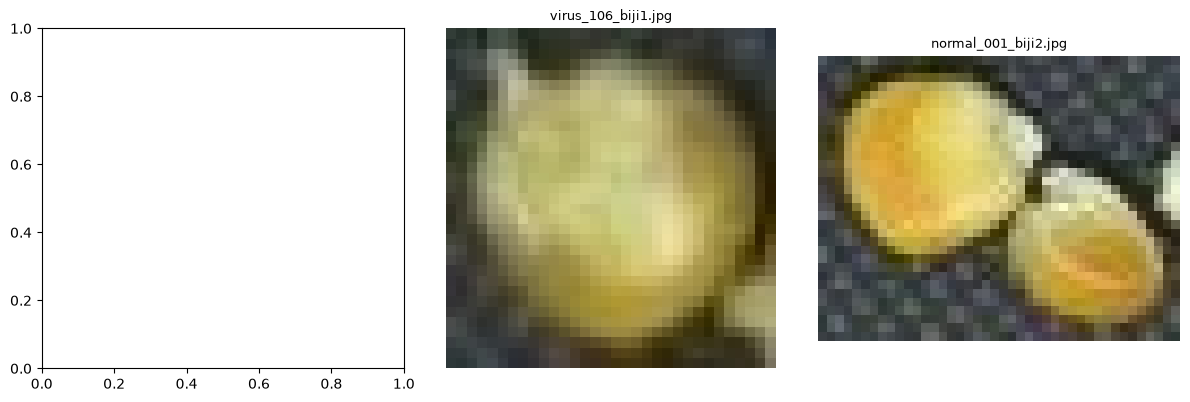

In [13]:
import matplotlib.pyplot as plt
import cv2
import os

kandidat_baru = [
    ("normal_109_biji2.jpg", "sehat"),
    ("virus_106_biji1.jpg", "terkontaminasi"),
    ("normal_001_biji2.jpg", "sehat"),
]

fig, axes = plt.subplots(1, len(kandidat_baru), figsize=(12, 4))

for ax, (nama_file, label) in zip(axes, kandidat_baru):
    path_file = os.path.join("../data/cropped", label, nama_file)
    img = cv2.imread(path_file)
    if img is None:
        print(f"GAGAL BACA: {path_file}")
        continue
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)
    ax.set_title(nama_file, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [14]:
import pandas as pd
import os

manifest = pd.read_csv("../data/manifest_crop.csv")
print("Jumlah baris SEBELUM dibuang:", len(manifest))

# 3 file noise round ini: 2 yang kelewat dari list lama + 1 kandidat baru yang baru dikonfirmasi
noise_round_ini = [
    "virus_059_biji4.jpg",   # kelewat dari daftar 6 noise original
    "normal_026_biji2.jpg",  # kelewat dari daftar 6 noise original
    "normal_109_biji2.jpg",  # baru dikonfirmasi visual
]

manifest_bersih = manifest[~manifest["filename"].isin(noise_round_ini)]
print("Jumlah baris SETELAH dibuang:", len(manifest_bersih))  # harus 550 - 3 = 547

manifest_bersih.to_csv("../data/manifest_crop.csv", index=False)
print("manifest_crop.csv sudah diperbarui.")

# langsung bersihkan folder fisik juga, sekalian
folder_sehat = "../data/cropped/sehat"
folder_kontam = "../data/cropped/terkontaminasi"
file_valid = set(manifest_bersih["filename"])

jumlah_terhapus = 0
for f in os.listdir(folder_sehat):
    if f not in file_valid:
        os.remove(os.path.join(folder_sehat, f))
        jumlah_terhapus += 1
for f in os.listdir(folder_kontam):
    if f not in file_valid:
        os.remove(os.path.join(folder_kontam, f))
        jumlah_terhapus += 1

print(f"Total file fisik dihapus: {jumlah_terhapus}")
print("Sisa sehat/:", len(os.listdir(folder_sehat)))
print("Sisa terkontaminasi/:", len(os.listdir(folder_kontam)))

Jumlah baris SEBELUM dibuang: 235
Jumlah baris SETELAH dibuang: 235
manifest_crop.csv sudah diperbarui.
Total file fisik dihapus: 315
Sisa sehat/: 146
Sisa terkontaminasi/: 89


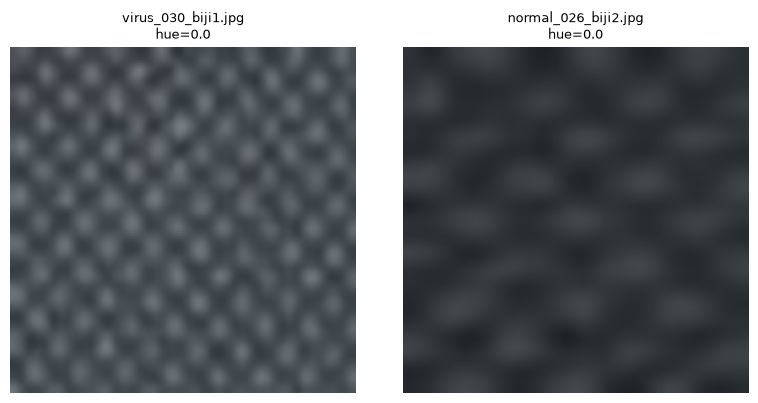

In [16]:
import matplotlib.pyplot as plt

kandidat = ["virus_030_biji1.jpg", "normal_026_biji2.jpg"]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

for i, nama_file in enumerate(kandidat):
    df_lookup = df_fitur_clean if "df_fitur_clean" in globals() else df_fitur
    row = df_lookup[df_lookup["filename"] == nama_file]

    if row.empty:
        # file may already be removed from the cleaned feature table
        label = "terkontaminasi" if nama_file.startswith("virus") else "sehat"
        row = pd.Series({
            "filename": nama_file,
            "label": label,
            "hue": 0.0
        })
    else:
        row = row.iloc[0]
    path_crop = f"../data/cropped/{row['label']}/{nama_file}"
    path_pre = f"../data/preprocessed/{row['label']}/{nama_file}"

    img = cv2.imread(path_pre)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    axes[i].imshow(img_rgb)
    axes[i].set_title(f"{nama_file}\nhue={row['hue']:.1f}", fontsize=9)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [17]:
bad_files = ["virus_030_biji1.jpg", "normal_026_biji2.jpg"]
df_fitur_clean = df_fitur[~df_fitur["filename"].isin(bad_files)].reset_index(drop=True)

print(f"Sebelum dibuang: {len(df_fitur)} baris")
print(f"Setelah dibuang: {len(df_fitur_clean)} baris")
print(df_fitur_clean["label"].value_counts())

df_fitur_clean.to_csv("../data/manifest_fitur.csv", index=False)

Sebelum dibuang: 235 baris
Setelah dibuang: 235 baris
label
sehat             146
terkontaminasi     89
Name: count, dtype: int64
